## Functions

In [1]:
import wandb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict
 
WANDB_ENTITY = "alvomatias_project"
WANDB_PROJECT = "inventory_control"
 
 
# ---------------------------------------------------------------------------
# Data fetching
# ---------------------------------------------------------------------------
 
def fetch_sweep_runs(sweep_name: str) -> list:
    api = wandb.Api()
    sweep = api.sweep(f"{WANDB_ENTITY}/{WANDB_PROJECT}/{sweep_name}")
    runs = list(sweep.runs)
    print(f"Fetched {len(runs)} runs from sweep {sweep_name}")
    return runs
 
 
def compute_epoch_df(
    sweep_name: str,
    loss_metric: str,
    value_metrics: list[str],
    x_key: str = "stores",
    run_key: str = "run_idx",
    seed_key: str = "a_seed",
) -> pd.DataFrame:
    """
    Fetches all runs and returns a raw epoch-level DataFrame.
    One row per (x_val, run_val, seed_val, epoch).
 
    The optimality gap is computed as:
        opt_gap = loss[epoch] - floor(x_val, run_val)
    where floor = min loss across all seeds and epochs for that (x_val, run_val).
 
    Parameters
    ----------
    sweep_name    : W&B sweep ID
    loss_metric   : metric used to compute the optimality gap (also stored as a column)
    value_metrics : metrics to fetch and store as columns
    x_key         : config key for the grouping dimension (e.g. "stores")
    run_key       : config key identifying a unique policy (e.g. "run_idx")
    seed_key      : config key identifying the seed (e.g. "a_seed")
 
    Returns
    -------
    pd.DataFrame with columns:
        {x_key}, {run_key}, {seed_key}, epoch, {loss_metric}, opt_gap, *value_metrics
    Metrics that are missing for a given epoch are NaN.
    """
    runs = fetch_sweep_runs(sweep_name)
    all_keys = [loss_metric] + value_metrics
    identifier_keys = (x_key, run_key, seed_key)
 
    # --- Step 1: fetch histories ---
    run_data = {}
    for run in runs:
        cfg = run.config
        try:
            key = tuple(cfg[k] for k in identifier_keys)
        except KeyError as e:
            print(f"Skipping run {run.id}: missing config key {e}")
            continue
 
        history = run.history(keys=all_keys, pandas=True)
        if history.empty:
            continue
 
        available = [c for c in all_keys if c in history.columns]
        sub = history[available].dropna(subset=[loss_metric]).reset_index(drop=True)
        if sub.empty:
            continue
 
        run_data[key] = sub
 
    if not run_data:
        raise ValueError("No valid run data found.")
 
    print(f"Valid runs: {len(run_data)}")
 
    # --- Step 2: compute floor per (x_val, run_val) ---
    floor: dict[tuple, float] = defaultdict(lambda: np.inf)
    for (x_val, run_val, seed_val), sub in run_data.items():
        policy_key = (x_val, run_val)
        floor[policy_key] = min(floor[policy_key], float(sub[loss_metric].min()))
 
    # --- Step 3: build epoch-level rows ---
    records = []
    for (x_val, run_val, seed_val), sub in run_data.items():
        best    = floor[(x_val, run_val)]
        opt_gap = sub[loss_metric].values - best
 
        chunk = sub.copy()
        chunk.insert(0, x_key,    x_val)
        chunk.insert(1, run_key,  run_val)
        chunk.insert(2, seed_key, seed_val)
        chunk.insert(3, "epoch",  np.arange(len(chunk)))
        chunk["opt_gap"] = opt_gap
        records.append(chunk)
 
    result = pd.concat(records, ignore_index=True)
 
    # Reorder: identifiers first, then opt_gap, then metrics
    id_cols     = [x_key, run_key, seed_key, "epoch", loss_metric, "opt_gap"]
    metric_cols = [c for c in result.columns if c not in id_cols]
    return result[id_cols + metric_cols]
 
 
# ---------------------------------------------------------------------------
# Derived metrics (epoch-level)
# ---------------------------------------------------------------------------
 
def add_derived_metrics(
    epoch_df: pd.DataFrame,
    derived: dict[str, callable],
) -> pd.DataFrame:
    """
    Adds derived metric columns to the epoch-level DataFrame.
    Each callable receives the DataFrame and returns a Series.
 
    Parameters
    ----------
    epoch_df : output of compute_epoch_df
    derived  : dict mapping new column name -> callable(df) -> pd.Series
 
    Example
    -------
    derived = {
        "grad_ratio/pathwise_vs_cross": lambda df: (
            df["train/grad_norm/continuous/pathwise/true"]
            / df["train/grad_norm/continuous/cross_ppo/true"]
        ),
    }
 
    Returns
    -------
    epoch_df with new columns appended (original df is not mutated).
    """
    result = epoch_df.copy()
    for name, fn in derived.items():
        try:
            result[name] = fn(result)
        except Exception as e:
            print(f"Could not compute derived metric '{name}': {e}")
    return result
 
 
# ---------------------------------------------------------------------------
# Bucketing + aggregation
# ---------------------------------------------------------------------------
 
def compute_bucketed_metrics(
    epoch_df: pd.DataFrame,
    value_metrics: list[str],
    x_key: str = "stores",
    run_key: str = "run_idx",
    seed_key: str = "a_seed",
    bucket_metric: str = "opt_gap",
    bucket_width: float = 5.0,
) -> pd.DataFrame:
    """
    Aggregates epoch-level data into buckets using two-stage averaging:
      Stage 1: mean per (run_key, seed_key, bucket)  — equal epoch weight per run
      Stage 2: simple average across (run_key, seed_key) — equal run weight
 
    Parameters
    ----------
    epoch_df      : output of compute_epoch_df (optionally with derived columns added)
    value_metrics : columns to aggregate
    x_key         : grouping dimension column (e.g. "stores")
    run_key       : run identity column (e.g. "run_idx")
    seed_key      : seed identity column (e.g. "a_seed")
    bucket_metric : column to bucketize on (e.g. "opt_gap" or any value metric)
    bucket_width  : width of each bucket
 
    Returns
    -------
    Wide-format pd.DataFrame with columns:
        {x_key}, bucket_left, bucket_right, {metric_1}, {metric_2}, ...
    One row per (x_val, bucket). Missing metric/bucket combos are NaN.
    """
    df = epoch_df.copy()
    df["bucket_left"] = (df[bucket_metric] // bucket_width) * bucket_width
 
    agg_records = []
    for x_val in df[x_key].unique():
        sub_x = df[df[x_key] == x_val]
 
        bucket_agg: dict[float, dict] = {}
        for metric in value_metrics:
            if metric not in sub_x.columns:
                continue
 
            rows = sub_x[[run_key, seed_key, "bucket_left", metric]].dropna(subset=[metric])
            if rows.empty:
                continue
 
            # Stage 1: mean per (run, seed, bucket)
            per_run = (
                rows.groupby([run_key, seed_key, "bucket_left"])[metric]
                .mean()
                .reset_index()
                .rename(columns={metric: "run_mean"})
            )
 
            # Stage 2: simple average across runs
            agg = (
                per_run.groupby("bucket_left")["run_mean"]
                .mean()
                .reset_index()
                .rename(columns={"run_mean": metric})
            )
 
            for _, row in agg.iterrows():
                bl = row["bucket_left"]
                if bl not in bucket_agg:
                    bucket_agg[bl] = {x_key: x_val, "bucket_left": bl,
                                      "bucket_right": bl + bucket_width}
                bucket_agg[bl][metric] = row[metric]
 
        agg_records.extend(bucket_agg.values())
 
    result = pd.DataFrame(agg_records)
    id_cols     = [x_key, "bucket_left", "bucket_right"]
    metric_cols = [c for c in result.columns if c not in id_cols]
    result = result[id_cols + metric_cols]
    result = result.sort_values([x_key, "bucket_left"]).reset_index(drop=True)
    return result
 
 
# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------
 
def plot_metric_vs_x(
    df: pd.DataFrame,
    x_key: str,
    filter_key: str,
    filter_value: float,
    value_metrics: list[str],
    bucket_width: float,
    xlabel: str = None,
    ylabel: str = "Mean value",
    title: str | None = None,
    xlim: tuple | None = None,
    ylim: tuple | None = None,
    out_file: str | None = None,
) -> None:
    """
    Generic plot: x_key on x-axis, filter_key fixed to filter_value, one line per metric.
    Line labels use the last two slash-separated sections of the metric name.
 
    Typical usage A — x=stores, filter on gap bucket:
        plot_metric_vs_x(df, x_key="stores", filter_key="bucket_left", filter_value=0.0, ...)
 
    Typical usage B — x=gap bucket, filter on stores:
        plot_metric_vs_x(df, x_key="bucket_left", filter_key="stores", filter_value=10, ...)
 
    Parameters
    ----------
    df           : output of compute_bucketed_metrics
    x_key        : column to use as x-axis (e.g. "stores" or "bucket_left")
    filter_key   : column to filter on (e.g. "bucket_left" or "stores")
    filter_value : value to keep in filter_key
    value_metrics: metric columns to plot (controls order)
    bucket_width : used only for auto-generating the title
    ylabel       : y-axis label
    title        : plot title (auto-generated if None)
    ylim         : optional (ymin, ymax)
    out_file     : if given, saves the figure here
    """
    filtered = df[np.isclose(df[filter_key].astype(float), float(filter_value))]
    if filtered.empty:
        print(f"No data for {filter_key}={filter_value}.")
        print(f"Available values: {sorted(df[filter_key].unique())}")
        return
 
    filtered = filtered.sort_values(x_key)
 
    fig, ax = plt.subplots(figsize=(8, 5))
 
    for metric in value_metrics:
        if metric not in filtered.columns:
            print(f"  No data for metric: {metric}")
            continue
        sub = filtered[[x_key, metric]].dropna(subset=[metric])
        label = "/".join(metric.split("/")[-3:])
        ax.plot(sub[x_key], sub[metric], marker="o", label=label)
 
    if title is None:
        if filter_key == "bucket_left":
            title = f"opt gap ∈ [{filter_value:.1f}, {filter_value + bucket_width:.1f})"
        else:
            title = f"{filter_key}={filter_value}"
    
    ax.set_xlabel(x_key)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend()
    plt.tight_layout()
 
    if out_file:
        plt.savefig(out_file, dpi=150)
        print(f"Saved to {out_file}")
    plt.show()

In [2]:
def plot_metric_vs_x_multi(
    df: pd.DataFrame,
    x_key: str,
    filter_key: str,
    filter_values: list[float],
    value_metrics: list[str],
    bucket_width: float,
    xlabel: str = None,
    ylabel: str = "Mean value",
    title: str | None = None,
    xlim: tuple | None = None,
    ylim: tuple | None = None,
    out_file: str | None = None,
) -> None:
    """
    Like plot_metric_vs_x, but plots one line per filter_value instead of one line per metric.
    Useful when you want to compare the same metric across multiple filter conditions
    (e.g. different store counts, or different opt-gap buckets).

    When len(value_metrics) == 1, each line is labeled by its filter_value.
    When len(value_metrics) > 1, lines are labeled "{filter_value} | {metric_label}".

    Parameters
    ----------
    df            : output of compute_bucketed_metrics
    x_key         : column to use as x-axis (e.g. "stores" or "bucket_left")
    filter_key    : column whose values define the lines (e.g. "stores" or "bucket_left")
    filter_values : list of values to keep from filter_key (one line each)
    value_metrics : metric columns to plot
    bucket_width  : used for auto-generating the title
    xlabel        : x-axis label (defaults to x_key)
    ylabel        : y-axis label
    title         : plot title (auto-generated if None)
    xlim          : optional (xmin, xmax)
    ylim          : optional (ymin, ymax)
    out_file      : if given, saves the figure here
    """
    multi_metric = len(value_metrics) > 1

    # Cycle colours across filter values; use linestyles across metrics
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    linestyles = ["-", "--", "-.", ":"]

    fig, ax = plt.subplots(figsize=(8, 5))

    for i, fv in enumerate(filter_values):
        filtered = df[np.isclose(df[filter_key].astype(float), float(fv))]
        if filtered.empty:
            print(f"No data for {filter_key}={fv}. "
                  f"Available: {sorted(df[filter_key].unique())}")
            continue
        filtered = filtered.sort_values(x_key)
        color = color_cycle[i % len(color_cycle)]

        # Build a short label for the filter value
        if filter_key == "bucket_left":
            fv_label = f"gap=[{fv:.0f},{fv + bucket_width:.0f})"
        else:
            fv_label = f"{filter_key}={fv}"

        for j, metric in enumerate(value_metrics):
            if metric not in filtered.columns:
                print(f"  No data for metric: {metric}")
                continue
            sub = filtered[[x_key, metric]].dropna(subset=[metric])
            metric_label = "/".join(metric.split("/")[-3:])
            label = f"{fv_label} | {metric_label}" if multi_metric else fv_label
            ax.plot(
                sub[x_key], sub[metric],
                marker="o",
                color=color,
                linestyle=linestyles[j % len(linestyles)],
                label=label,
            )

    if title is None:
        fv_str = ", ".join(
            f"[{fv:.0f},{fv + bucket_width:.0f})" if filter_key == "bucket_left"
            else str(fv)
            for fv in filter_values
        )
        title = f"{filter_key} ∈ {{{fv_str}}}"

    ax.set_xlabel(xlabel if xlabel is not None else x_key)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend()
    plt.tight_layout()

    if out_file:
        plt.savefig(out_file, dpi=150)
        print(f"Saved to {out_file}")
    plt.show()

In [3]:
def plot_scatter_with_regression(
    df: pd.DataFrame,
    x_metric: str,
    y_metric: str,
    color_key: str,
    bucket_width: float,
    filter_key: str | None = None,
    filter_value: float | None = None,
    xlabel: str | None = None,
    ylabel: str | None = None,
    title: str | None = None,
    xlim: tuple | None = None,
    ylim: tuple | None = None,
    x_log: bool = False,
    point_size: float = 50,
    alpha: float = 0.6,
    jitter: float = 0.0,
    show_regression: bool = True,
    regression_degree: int = 1,
    regime_x: tuple | float | None = None,
    cmap_name: str = "viridis",
    out_file: str | None = None,
) -> None:
    """
    Scatterplot of x_metric vs y_metric, color-coded by color_key using a
    sequential colormap (darker = higher value), with an optional polynomial
    regression line and a shaded regime band.

    Each point is assumed to be an already-aggregated (color_key, bucket) mean,
    so no further binning is applied.

    Parameters
    ----------
    df                : output of compute_bucketed_metrics
    x_metric          : column for x-axis
    y_metric          : column for y-axis
    color_key         : column whose values determine point colors (e.g. "stores")
    bucket_width      : used for auto title when filter_key == "bucket_left"
    filter_key        : column to filter on before plotting; None = no filter
    filter_value      : value to keep in filter_key
    xlabel            : x-axis label
    ylabel            : y-axis label
    title             : plot title (auto-generated if None)
    xlim              : optional (xmin, xmax)
    ylim              : optional (ymin, ymax)
    x_log             : if True, use log scale on x-axis
    point_size        : marker size
    alpha             : point opacity
    jitter            : std of Gaussian noise added to x and y (0 = disabled)
    show_regression   : if True, overlay a polynomial regression line across all points
    regression_degree : degree of the polynomial fit (1 = linear, 2 = quadratic)
    regime_x          : marks the experimental regime on the x-axis.
                        - float : a single vertical dashed line
                        - tuple : a shaded band (x_lo, x_hi)
                        - None  : disabled
    cmap_name         : matplotlib colormap name for the color_key gradient
                        (e.g. "viridis", "plasma", "YlOrRd", "Blues")
    out_file          : if given, saves the figure here
    """
    df = df.copy()

    # --- Optional filter ---
    if filter_key is not None:
        if filter_value is None:
            raise ValueError("filter_value must be provided when filter_key is set.")
        df = df[np.isclose(df[filter_key].astype(float), float(filter_value))]
        if df.empty:
            print(f"No data for {filter_key}={filter_value}.")
            print(f"Available values: {sorted(df[filter_key].unique())}")
            return

    df = df.dropna(subset=[x_metric, y_metric])
    if df.empty:
        print("No data after dropping NaNs.")
        return

    # --- Color map (sequential, one shade per color_key value) ---
    color_values = sorted(df[color_key].unique())
    cmap         = plt.cm.get_cmap(cmap_name)
    norm = plt.matplotlib.colors.LogNorm(vmin=min(color_values), vmax=max(color_values))
    color_map    = {v: cmap(norm(v)) for v in color_values}

    fig, ax = plt.subplots(figsize=(7, 5))
    rng = np.random.default_rng(seed=0)

    # --- Scatter ---
    for val in color_values:
        sub    = df[df[color_key] == val]
        x_vals = sub[x_metric].values.astype(float)
        y_vals = sub[y_metric].values.astype(float)

        if jitter > 0.0:
            x_vals = x_vals + rng.normal(0, jitter, size=len(x_vals))
            y_vals = y_vals + rng.normal(0, jitter, size=len(y_vals))

        ax.scatter(
            x_vals, y_vals,
            color=color_map[val],
            alpha=alpha,
            edgecolors="none",
            s=point_size,
            zorder=2,
        )

    # --- Colorbar ---
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(color_key)
    cbar.set_ticks(color_values)
    cbar.set_ticklabels(color_values)

    # --- Regression line ---
    if show_regression:
        all_x   = df[x_metric].values.astype(float)
        all_y   = df[y_metric].values.astype(float)
        x_fit   = np.log(all_x) if x_log else all_x
        coeffs  = np.polyfit(x_fit, all_y, deg=regression_degree)
        poly    = np.poly1d(coeffs)

        x_range     = np.linspace(all_x.min(), all_x.max(), 300)
        x_range_fit = np.log(x_range) if x_log else x_range
        y_range     = poly(x_range_fit)

        r, pval   = pearsonr(x_fit, all_y)
        reg_label = f"fit (deg={regression_degree}, r={r:.2f})"
        ax.plot(
            x_range, y_range,
            color="black", linewidth=1.8,
            linestyle="--", label=reg_label,
            zorder=3,
        )
        ax.legend(fontsize=8)

    # --- Regime marker ---
    if regime_x is not None:
        if isinstance(regime_x, tuple):
            ax.axvspan(
                regime_x[0], regime_x[1],
                alpha=0.12, color="gray",
                label="experimental regime",
                zorder=1,
            )
        else:
            ax.axvline(
                regime_x, color="gray",
                linewidth=1.5, linestyle=":",
                label=f"experimental regime (x={regime_x:.2f})",
                zorder=1,
            )

    # --- Log scale ---
    if x_log:
        ax.set_xscale("log")

    # --- Labels and title ---
    ax.set_xlabel(xlabel if xlabel is not None else "/".join(x_metric.split("/")[-3:]))
    ax.set_ylabel(ylabel if ylabel is not None else "/".join(y_metric.split("/")[-3:]))

    if title is None:
        if filter_key == "bucket_left" and filter_value is not None:
            title = f"opt gap ∈ [{filter_value:.1f}, {filter_value + bucket_width:.1f})"
        elif filter_key is not None and filter_value is not None:
            title = f"{filter_key}={filter_value}"
        else:
            title = f"{'/'.join(x_metric.split('/')[-2:])} vs {'/'.join(y_metric.split('/')[-2:])}"

    ax.set_title(title)
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    plt.tight_layout()

    if out_file:
        plt.savefig(out_file, dpi=150)
        print(f"Saved to {out_file}")
    plt.show()

## Run functions

### Cosine similarity experiments

In [4]:
# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    # SWEEP_NAME   = "2afiqo15"
    # SWEEP_NAME   = "n8ffl8wg"
    SWEEP_NAME   = "7gbdtzpq"
    # SWEEP_NAME   = "klgu3soi"
    # SWEEP_NAME   = "or36pd9x"
    # SWEEP_NAME   = "nsqru5dy"
    # LOSS_METRIC  = "dev/loss/reported"
    LOSS_METRIC  = "train/loss/reported"
    d            = 512

    VALUE_METRICS = [
        f"train/alignment_{d}/continuous/continuous_ppo",
        f"train/alignment_{d}/continuous/cross_ppo",
        f"train/alignment_{d}/discrete/cross_ppo",
        f"train/alignment_{d}/continuous/pathwise",
        f"train/alignment_{d}/continuous/pathwise_plus_cross_ppo",
        f"train/grad_norm/continuous/continuous_ppo/true",
        f"train/grad_norm/continuous/cross_ppo/true",
        f"train/grad_norm/discrete/cross_ppo/true",
        f"train/grad_norm/continuous/pathwise/true",
        f"train/grad_norm/continuous/pathwise_plus_cross_ppo/true",
        f"train/grad_norm/continuous/continuous_ppo/var",
        f"train/grad_norm/discrete/cross_ppo/var",
        f"train/grad_norm/continuous/cross_ppo/var",
        f"train/grad_norm/continuous/pathwise/var",
        f"train/grad_norm/continuous/pathwise_plus_cross_ppo/var",
        f"train/loo_cosine_{d}/continuous/pathwise_vs_pathwise_plus_cross_ppo/mean",
        f"train/loo_cosine_{d}/continuous/pathwise_plus_cross_ppo/mean",
        f"train/signal_{d}/continuous/continuous_ppo",
        f"train/signal_{d}/continuous/cross_ppo",
        f"train/signal_{d}/discrete/cross_ppo",
        f"train/signal_{d}/continuous/pathwise",
        f"train/signal_{d}/continuous/pathwise_plus_cross_ppo",
        f"train/noise_{d}/continuous/continuous_ppo",
        f"train/noise_{d}/continuous/cross_ppo",
        f"train/noise_{d}/discrete/cross_ppo",
        f"train/noise_{d}/continuous/pathwise",
        f"train/noise_{d}/continuous/pathwise_plus_cross_ppo",
    ]

    # Step 1: fetch raw epoch-level data
    epoch_df = compute_epoch_df(
        sweep_name=SWEEP_NAME,
        loss_metric=LOSS_METRIC,
        value_metrics=VALUE_METRICS,
        x_key="stores",
        run_key="run_idx",
        seed_key="a_seed",
    )

    


wandb: Currently logged in as: alvomatias (alvomatias_project) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Fetched 72 runs from sweep 7gbdtzpq
Valid runs: 71


In [9]:
if __name__ == "__main__":
# Step 2: add derived metrics at the epoch level
    DERIVED = {
        "grad_ratio/pathwise_vs_cross": lambda df: (
            df[f"train/grad_norm/continuous/pathwise/true"]
            / (df[f"train/grad_norm/continuous/cross_ppo/true"] + df[f"train/grad_norm/continuous/pathwise/true"])
        ),
    }
    epoch_df = add_derived_metrics(epoch_df, DERIVED)

    print(epoch_df.head())

   stores  run_idx  a_seed  epoch  train/loss/reported    opt_gap  \
0       1        0       0      0            74.854158  33.563456   
1       1        0       0      1            74.986032  33.695331   
2       1        0       0      2            75.286278  33.995577   
3       1        0       0      3            75.102650  33.811949   
4       1        0       0      4            75.092117  33.801416   

   train/alignment_512/continuous/continuous_ppo  \
0                                      -0.011667   
1                                       0.434121   
2                                       0.449484   
3                                       0.351697   
4                                      -0.022847   

   train/alignment_512/continuous/cross_ppo  \
0                                  0.335880   
1                                  0.734350   
2                                  0.800135   
3                                  0.668281   
4                                  0.

In [16]:
if __name__ == "__main__":
    BUCKET_METRIC = "opt_gap"
    BUCKET_WIDTH = 1
    # BUCKET_METRIC = "grad_ratio/pathwise_vs_cross"    
    # BUCKET_WIDTH = 0.1
    

# Step 3: bucketize (on opt_gap by default, but can use any column)
    bucketed_df = compute_bucketed_metrics(
        epoch_df=epoch_df,
        value_metrics=VALUE_METRICS + list(DERIVED.keys()) + ["opt_gap"],
        x_key="stores",
        run_key="run_idx",
        seed_key="a_seed",
        bucket_metric=BUCKET_METRIC,
        bucket_width=BUCKET_WIDTH,
    )
    print(bucketed_df.head())

   stores  bucket_left  bucket_right  \
0       1          0.0           1.0   
1       1          1.0           2.0   
2       1          2.0           3.0   
3       1          3.0           4.0   
4       1          4.0           5.0   

   train/alignment_512/continuous/continuous_ppo  \
0                                       0.221154   
1                                       0.187815   
2                                       0.129843   
3                                       0.159602   
4                                       0.137588   

   train/alignment_512/continuous/cross_ppo  \
0                                  0.006321   
1                                  0.004608   
2                                  0.031324   
3                                  0.033588   
4                                  0.041685   

   train/alignment_512/discrete/cross_ppo  \
0                                0.046086   
1                                0.358764   
2                           

In [17]:
gradients = ["continuous/pathwise_plus_cross_ppo",
            "continuous/continuous_ppo",
            "continuous/cross_ppo",
            "continuous/pathwise",
            "continuous/pathwise_plus_cross_ppo",
            "discrete/cross_ppo",
            ]

# Compute signal to noise ratio (SNR) for grad norm:
# SNR = mean / std = true / sqrt(var)
snr_metrics = [
    (f"train/signal_{d}/{g}", f"train/noise_{d}/{g}", f"grad_norm/{g}/snr")
    for g in gradients
]

# compute the sqrt of signal and the sqrt of noise for each gradient
sqrt_metrics = [
    (f"train/signal_{d}/{g}", f"train/noise_{d}/{g}", f"train/sqrt_signal_{d}/{g}", f"train/sqrt_noise_{d}/{g}")
    for g in gradients
]

for true_key, var_key, snr_key in snr_metrics:
    if true_key in bucketed_df.columns and var_key in bucketed_df.columns:
        bucketed_df[snr_key] = (bucketed_df[true_key].clip(lower=0) / bucketed_df[var_key])**0.5

for true_key, var_key, sqrt_signal_key, sqrt_noise_key in sqrt_metrics:
    if true_key in bucketed_df.columns and var_key in bucketed_df.columns:
        bucketed_df[sqrt_signal_key] = bucketed_df[true_key].clip(lower=0)**0.5
        bucketed_df[sqrt_noise_key] = bucketed_df[var_key]**0.5

bucketed_df[f"signal_{d}_ratio"] = bucketed_df[f"train/signal_{d}/continuous/pathwise"].clip(lower=0) / (bucketed_df[f"train/signal_{d}/continuous/cross_ppo"].clip(lower=0) + bucketed_df[f"train/signal_{d}/continuous/pathwise"].clip(lower=0))

In [18]:
if __name__ == "__main__":

    BUCKET   = 20.0
    gradients_index = 3
    vm_index = 4
    stores = 10
    xlim = None
    ylim = None
    xlim = (-1, 70)
    # ylim = (0, 2)

    # --- Gradient comparison groups (pick index below) ---
    gradient_groups = [
        # 0: pathwise_plus_cross vs ppo
        [
            "continuous/pathwise_plus_cross_ppo",
            # "continuous/continuous_ppo",
        ],

        # 1: cross term comparison
        [
            "discrete/cross_ppo",
            "continuous/cross_ppo",
        ],
        # 2: pathwise vs pathwise_plus_cross
        [
            "continuous/pathwise",
            "continuous/pathwise_plus_cross_ppo",
        ],

        # 3: cross term comparison
        [
            "continuous/cross_ppo",
        ],

        # 4: pathwise vs cross
        [
            "continuous/pathwise",
            "continuous/cross_ppo",
        ],

        # 5: pathwise, cross and hybrid
        [
            "continuous/pathwise",
            # "continuous/cross_ppo",
            # "continuous/pathwise_plus_cross_ppo",
        ],

        # 6: continuous ppo
        [
            # "continuous/continuous_ppo",
            "continuous/cross_ppo",
        ],
    ]

    gradients = gradient_groups[gradients_index]

    # --- Build metric lists dynamically ---
    vm0 = [f"train/alignment_{d}/{g}" for g in gradients]
    vm1 = [f"grad_norm/{g}/snr" for g in gradients]
    vm2 = [
        f"train/loo_cosine_{d}/continuous/pathwise_vs_pathwise_plus_cross_ppo/mean",
        f"train/loo_cosine_{d}/continuous/pathwise_plus_cross_ppo/mean",
        f"signal_{d}_ratio",
    ]
    vm3 = [f"train/sqrt_signal_{d}/{g}" for g in gradients]

    vm4 = [f"train/sqrt_noise_{d}/{g}" for g in gradients]

    # --- Y-axis labels aligned to each vm ---
    ylabels = [
        "Alignment",             # vm0
        "Signal / noise (est.)", # vm1
        "Cosine similarity",     # vm2
        "Estimated norm of mean",  # vm3
        "Estimated sqrt(trace of covariance matrix)",      # vm4
    ]

    vms = [vm0, vm1, vm2, vm3, vm4]
    vm = vms[vm_index]
    ylabel = ylabels[vm_index]

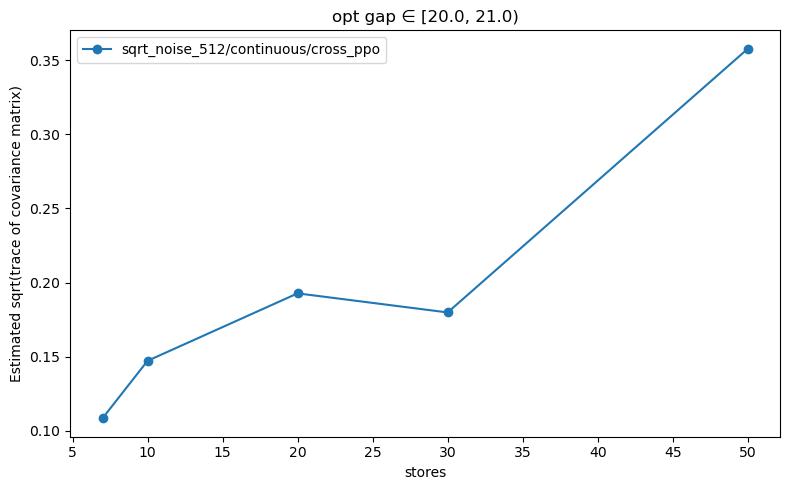

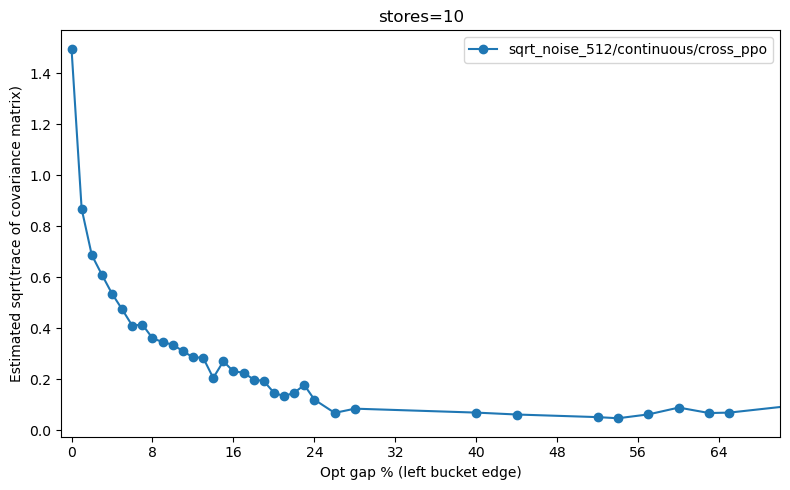

In [19]:
if __name__ == "__main__":

# Plot alignment metrics
    plot_metric_vs_x(
        df=bucketed_df,
        x_key="stores",
        filter_key="bucket_left",
        filter_value=BUCKET,
        value_metrics=vm,
        bucket_width=BUCKET_WIDTH,
        ylabel=ylabel,
    )

    plot_metric_vs_x(
        df=bucketed_df,
        x_key="bucket_left",
        xlabel="Opt gap % (left bucket edge)",
        filter_key="stores",
        filter_value=stores,
            value_metrics=vm,
        bucket_width=BUCKET_WIDTH,
        ylabel=ylabel,
        xlim=xlim,
        ylim=ylim,
    )

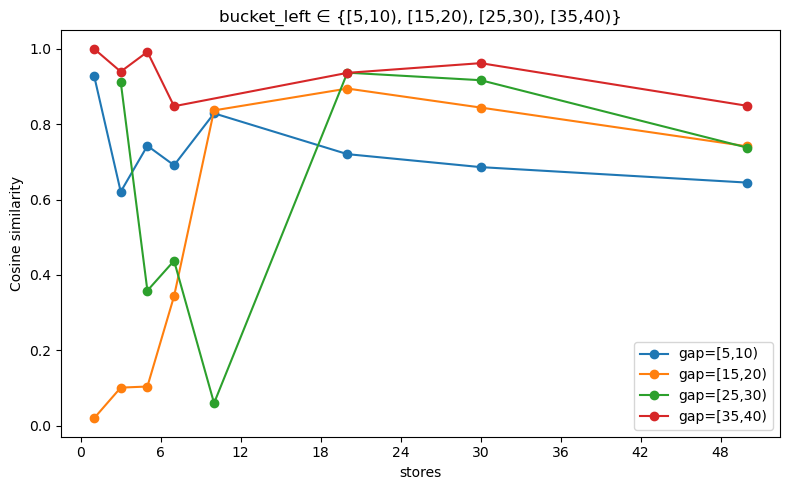

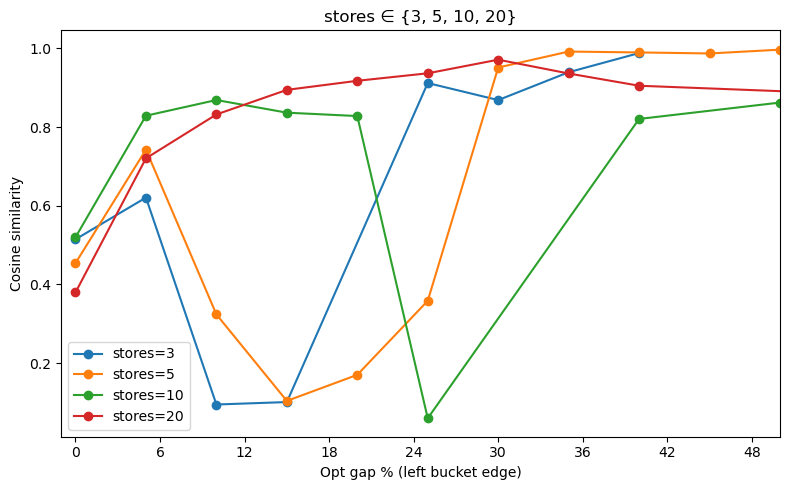

In [9]:
if __name__ == "__main__":

    # Compare multiple opt-gap buckets, x=stores
    plot_metric_vs_x_multi(
        df=bucketed_df,
        x_key="stores",
        filter_key="bucket_left",
        filter_values=[5.0, 15.0, 25.0, 35.0],
        value_metrics=vm,
        bucket_width=BUCKET_WIDTH,
        ylabel=ylabel,
    )

    # Compare multiple store counts, x=opt-gap bucket
    plot_metric_vs_x_multi(
        df=bucketed_df,
        x_key="bucket_left",
        xlabel="Opt gap % (left bucket edge)",
        filter_key="stores",
        filter_values=[3, 5, 10, 20],
        # filter_values=[3, 10, 30, 50],
        value_metrics=vm,
        bucket_width=BUCKET_WIDTH,
        ylabel=ylabel,
        xlim=[-1,50],
        ylim=ylim,
    )

/tmp/ipykernel_118463/1347572244.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap         = plt.cm.get_cmap(cmap_name)


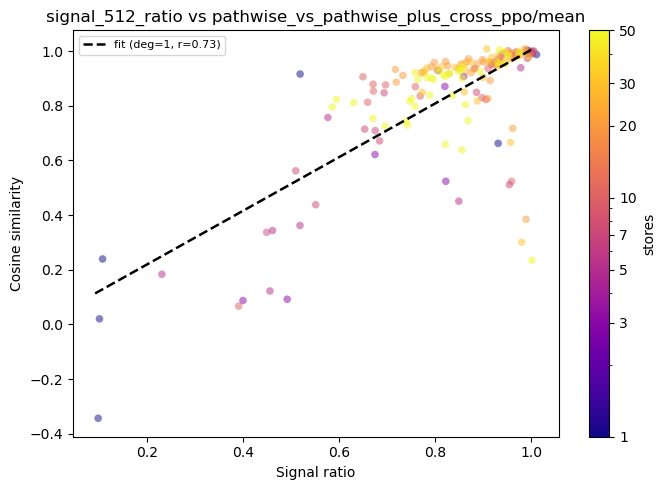

In [34]:
plot_scatter_with_regression(
    df=bucketed_df,
    x_metric=f"signal_{d}_ratio",
    y_metric=f"train/loo_cosine_{d}/continuous/pathwise_vs_pathwise_plus_cross_ppo/mean",
    color_key="stores",
    bucket_width=BUCKET_WIDTH,
    filter_key=None,
    filter_value=None,
    xlabel="Signal ratio",
    ylabel="Cosine similarity",
    show_regression=True,
    regression_degree=1,       # quadratic looks better for a saturating relationship
    # regime_x=(0.85, 1.0),      # shade the region where your experiments actually live
    point_size=30,
    alpha=0.5,
    jitter=0.01,
    cmap_name="plasma",
)

### Empirical performance

Fetched 88 runs from sweep xs0iw9x4
Skipping run 3vxdmd9i (hybrid, stores=50): metric 'test/loss/reported' not in summary
Skipping run mi60qvd1 (hybrid, stores=50): metric 'test/loss/reported' not in summary
Skipping run kg55b1eu (hybrid, stores=7): metric 'test/loss/reported' not in summary
Skipping run gcc9ohvf (hybrid, stores=30): metric 'test/loss/reported' not in summary
Skipping run x695iww2 (hybrid, stores=20): metric 'test/loss/reported' not in summary
Skipping run wrj9rosg (hybrid, stores=5): metric 'test/loss/reported' not in summary
Skipping run d1o4nlws (hybrid, stores=10): metric 'test/loss/reported' not in summary
Skipping run an50g0uv (hybrid, stores=7): metric 'test/loss/reported' not in summary
Fetched 88 runs from sweep 8yd4la7p
Skipping run a9jeiddn (gaussian_ppo, stores=1): metric 'test/loss/reported' not in summary
Skipping run zuqfibao (gaussian_ppo, stores=1): metric 'test/loss/reported' not in summary
Skipping run yavtefff (gaussian_ppo, stores=7): metric 'test/

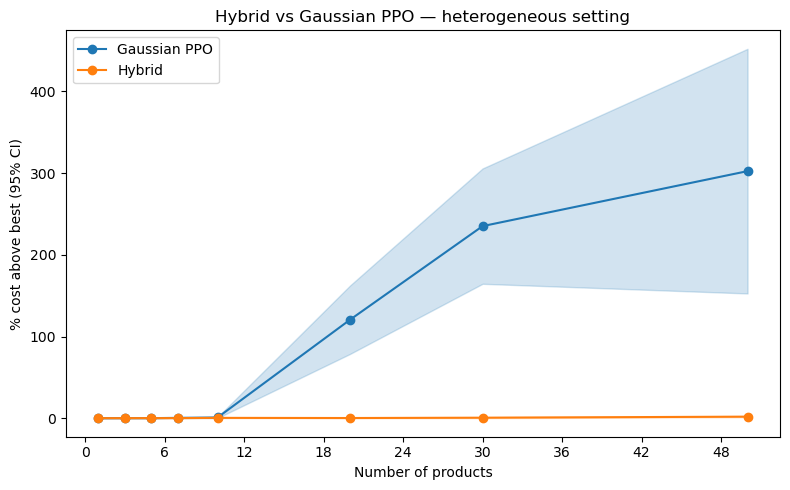

           agent  stores        mean     ci_half   n
0   Gaussian PPO       1    0.083610    0.036853   8
1   Gaussian PPO       3    0.149342    0.029365  10
2   Gaussian PPO       5    0.151126    0.070393  10
3   Gaussian PPO       7    0.489347    0.110908   9
4   Gaussian PPO      10    0.963401    0.627803  10
5   Gaussian PPO      20  120.637224   41.877083  10
6   Gaussian PPO      30  235.137875   70.574874  11
7   Gaussian PPO      50  302.447400  149.702213  11
8         Hybrid       1    0.149579    0.055199  11
9         Hybrid       3    0.149331    0.049134  11
10        Hybrid       5    0.212118    0.094034  10
11        Hybrid       7    0.189035    0.119679   9
12        Hybrid      10    0.490449    0.238867  10
13        Hybrid      20    0.300190    0.279146  10
14        Hybrid      30    0.700598    0.565133  10
15        Hybrid      50    1.967087    0.738476   9


In [ ]:



WANDB_ENTITY = "alvomatias_project"
WANDB_PROJECT = "inventory_control"

PERFORMANCE_METRIC = "test/loss/reported"


# ---------------------------------------------------------------------------
# Data fetching
# ---------------------------------------------------------------------------

def fetch_sweep_runs(sweep_name: str) -> list:
    api = wandb.Api()
    sweep = api.sweep(f"{WANDB_ENTITY}/{WANDB_PROJECT}/{sweep_name}")
    runs = list(sweep.runs)
    print(f"Fetched {len(runs)} runs from sweep {sweep_name}")
    return runs


def fetch_agent_performance(
    sweep_names: list[str],
    metric: str = PERFORMANCE_METRIC,
    x_key: str = "stores",
    agent_rename: dict[str, str] | None = None,
) -> pd.DataFrame:
    """
    Fetches runs from one or more sweeps and returns a DataFrame with one row
    per run containing the agent type, x_key value, and metric value.

    The agent type is read from:
        run.config["hyperparams_config"]["agent_params"]["agent_type"]

    Parameters
    ----------
    sweep_names  : list of W&B sweep IDs
    metric       : scalar metric to fetch (e.g. "test/loss/reported")
    x_key        : config key for the x-axis grouping (e.g. "stores")
    agent_rename : optional dict mapping raw agent_type -> display name

    Returns
    -------
    pd.DataFrame with columns: agent, {x_key}, metric_value
    """
    if agent_rename is None:
        agent_rename = {}

    records = []
    seen_run_ids = set()

    for sweep_name in sweep_names:
        runs = fetch_sweep_runs(sweep_name)
        for run in runs:
            if run.id in seen_run_ids:
                continue
            seen_run_ids.add(run.id)

            cfg = run.config

            # --- extract agent type ---
            try:
                agent_type = cfg["hyperparams_config"]["agent_params"]["agent_type"]
            except (KeyError, TypeError):
                print(f"Skipping run {run.id}: could not find agent_type in hyperparams_config")
                continue

            # --- extract x_key ---
            if x_key not in cfg:
                print(f"Skipping run {run.id}: missing config key '{x_key}'")
                continue
            x_val = cfg[x_key]

            # --- extract metric summary value ---
            metric_val = run.summary.get(metric)
            if metric_val is None:
                print(f"Skipping run {run.id} ({agent_type}, {x_key}={x_val}): metric '{metric}' not in summary")
                continue

            agent_label = agent_rename.get(agent_type, agent_type)
            records.append({
                "agent": agent_label,
                x_key: x_val,
                "metric_value": float(metric_val),
            })

    df = pd.DataFrame(records)
    print(f"\nTotal valid runs: {len(df)}")
    if not df.empty:
        print(df.groupby(["agent", x_key]).size().rename("n_runs").to_string())
    return df


# ---------------------------------------------------------------------------
# Aggregation
# ---------------------------------------------------------------------------

def compute_performance_stats(
    df: pd.DataFrame,
    x_key: str = "stores",
    relative: bool = False,
    ci_level: float = 0.95,
) -> pd.DataFrame:
    """
    Computes mean and confidence interval for each (agent, x_key) combination.

    Parameters
    ----------
    df        : output of fetch_agent_performance
    x_key     : grouping dimension (e.g. "stores")
    relative  : if True, express performance as % above the best (lowest) run
                for each x_key value:
                    rel = (value / best_for_x - 1) * 100
    ci_level  : confidence level for the CI (default 0.95 → ±1.96 σ/√n)

    Returns
    -------
    pd.DataFrame with columns: agent, {x_key}, mean, ci_half, n
    """
    from scipy import stats as scipy_stats

    result_df = df.copy()

    if relative:
        # For each x_key value, find the minimum metric across ALL agents/runs
        best_per_x = result_df.groupby(x_key)["metric_value"].min().rename("best")
        result_df = result_df.join(best_per_x, on=x_key)
        result_df["metric_value"] = (result_df["metric_value"] / result_df["best"] - 1.0) * 100.0
        result_df = result_df.drop(columns=["best"])

    z = scipy_stats.norm.ppf(0.5 + ci_level / 2)

    records = []
    for (agent, x_val), grp in result_df.groupby(["agent", x_key]):
        vals = grp["metric_value"].dropna().values
        n = len(vals)
        mean = vals.mean()
        ci_half = z * vals.std(ddof=1) / np.sqrt(n) if n > 1 else 0.0
        records.append({"agent": agent, x_key: x_val, "mean": mean, "ci_half": ci_half, "n": n})

    stats_df = pd.DataFrame(records).sort_values(["agent", x_key]).reset_index(drop=True)
    return stats_df


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_agent_comparison(
    sweep_names: list[str],
    metric: str = PERFORMANCE_METRIC,
    x_key: str = "stores",
    relative: bool = False,
    agent_rename: dict[str, str] | None = None,
    xlabel: str | None = None,
    ylabel: str | None = None,
    title: str | None = None,
    xlim: tuple | None = None,
    ylim: tuple | None = None,
    ci_level: float = 0.95,
    out_file: str | None = None,
) -> pd.DataFrame:
    """
    Fetches runs from one or more sweeps and plots mean ± CI for each agent
    as a function of x_key (e.g. number of stores).

    Parameters
    ----------
    sweep_names  : list of W&B sweep IDs (runs from multiple sweeps are pooled)
    metric       : summary metric to use as performance (e.g. "test/loss/reported")
    x_key        : config key for the x-axis (e.g. "stores")
    relative     : if True, y-axis shows % cost above the best run per x value
    agent_rename : dict mapping raw agent_type strings to display labels,
                   e.g. {"gaussian_ppo": "Gaussian PPO", "hybrid": "Hybrid"}
    xlabel       : x-axis label (default: x_key)
    ylabel       : y-axis label (auto-generated if None)
    title        : plot title (auto-generated if None)
    xlim         : optional (xmin, xmax)
    ylim         : optional (ymin, ymax)
    ci_level     : confidence level for error bands (default 0.95)
    out_file     : if given, saves the figure here

    Returns
    -------
    stats_df : pd.DataFrame with aggregated mean / CI per (agent, x_key)
    """
    # --- fetch ---
    raw_df = fetch_agent_performance(
        sweep_names=sweep_names,
        metric=metric,
        x_key=x_key,
        agent_rename=agent_rename,
    )
    if raw_df.empty:
        print("No data found.")
        return raw_df

    # --- aggregate ---
    stats_df = compute_performance_stats(
        raw_df, x_key=x_key, relative=relative, ci_level=ci_level
    )

    # --- plot ---
    fig, ax = plt.subplots(figsize=(8, 5))

    agents = stats_df["agent"].unique()
    prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, agent in enumerate(sorted(agents)):
        sub = stats_df[stats_df["agent"] == agent].sort_values(x_key)
        color = prop_cycle[i % len(prop_cycle)]
        ax.plot(sub[x_key], sub["mean"], marker="o", label=agent, color=color)
        ax.fill_between(
            sub[x_key],
            sub["mean"] - sub["ci_half"],
            sub["mean"] + sub["ci_half"],
            alpha=0.2,
            color=color,
        )

    # --- labels / formatting ---
    ax.set_xlabel(xlabel if xlabel is not None else x_key)

    if ylabel is not None:
        ax.set_ylabel(ylabel)
    elif relative:
        ax.set_ylabel(f"% cost above best ({int(ci_level*100)}% CI)")
    else:
        ax.set_ylabel(f"{metric} ({int(ci_level*100)}% CI)")

    if title is not None:
        ax.set_title(title)
    else:
        mode = "relative %" if relative else "absolute"
        ax.set_title(f"Agent comparison — {metric} ({mode})")

    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.legend()
    plt.tight_layout()

    if out_file:
        plt.savefig(out_file, dpi=150)
        print(f"Saved to {out_file}")
    plt.show()

    return stats_df


# ---------------------------------------------------------------------------
# Example usage
# ---------------------------------------------------------------------------
if __name__ == "__main__":

    SWEEP_NAMES = [
        "xs0iw9x4",   # <-- replace with real sweep IDs
        "8yd4la7p",
    ]

    AGENT_RENAME = {
        "gaussian_ppo": "Gaussian PPO",
        "hybrid":       "Hybrid",
        # add more as needed
    }

    stats = plot_agent_comparison(
        sweep_names=SWEEP_NAMES,
        metric="test/loss/reported",
        x_key="stores",
        relative=False,             # set False for absolute costs
        agent_rename=AGENT_RENAME,
        xlabel="Number of products",
        ylabel="% cost above best (95% CI)",
        title="Hybrid vs Gaussian PPO — heterogeneous setting",
        # xlim=(0, 55),
        # ylim=(0, 10),
        ci_level=0.95,
        out_file="agent_comparison.png",
    )

    print(stats)